# h5py key inspect

HI
HI
[[1.8965149 1.9050115 1.8955301 ... 1.8280998 1.8525422 1.8792238]
 [1.8981142 1.9193597 1.9276042 ... 1.8194138 1.8530787 1.8747069]
 [1.8917929 1.9225353 1.9369822 ... 1.8177919 1.8340716 1.8628298]
 ...
 [1.9113656 1.9139694 1.9114035 ... 1.8835784 1.8886505 1.9089196]
 [1.9175192 1.9151796 1.9116644 ... 1.8513991 1.8719519 1.8976934]
 [1.9033449 1.9070817 1.9016067 ... 1.837027  1.8550195 1.8804593]]
(512, 512)


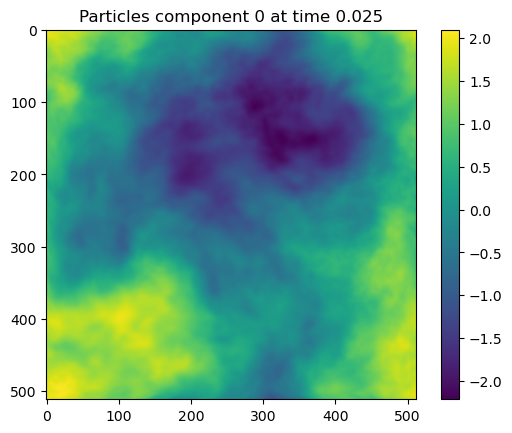

In [3]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# f = h5py.File(h5_filename,'r')
# for item in f.keys():
#     print item #+ ":", f[item]

postfix = 0        # sample index (0–3)
t_idx = 100        # time step index (0–999)
channel_idx = 0    # velocity component (0 for u, 1 for v)
split_ratios = [0.5, 0.25, 0.25]
total_samples = 4
train_end = int(split_ratios[0] * total_samples)
val_end = train_end + int(split_ratios[1] * total_samples)
test_end = train_end+val_end +int(split_ratios[2] * total_samples)
splits = {
        'train': slice(0, train_end),
        'val': slice(train_end, val_end),
        'test': slice(val_end, test_end)
}
# print(splits['train'])
# print(splits['val'])
# print(splits['test'])
# test_arr = [0, 1, 2, 3]
# print(test_arr[splits['train']])
# print(test_arr[splits['val']])
# print(test_arr[splits['test']])


with h5py.File("/sdcc/u/smccue/projects/inr_sampling/pde_bench/ns_incom_inhom_2d_512-0.h5", 'r') as f:
    print("HI")
    # raw = f['particles']
    # raw = np.squeeze(raw, axis=-1)
    # raw = np.transpose(raw, (1, 2, 3, 0))
    print("HI")
    # print(raw.shape)
    # # print(f.keys())
    # # for item in f.keys():
    # #     print(item)
    # #     print(f[item])
    data = f["particles"]

    # N, T, H, W, C = data.shape
    # data = data[..., 0]
    # transposed = np.empty((T, H, W, N), dtype=np.float32)
    # # print(data)
    # # print(data[0, 1, ...])
    # train_end = int(.15 * total_samples)
    # test_slice = data[0, 627, :, :, 0]  # shape: (512, 512)
    # print(test_slice)
    # print(test_slice.shape)

    # # for n in range(N):
    # #     print(f"Reading and transposing sample {n}")
    # #     sample = data[n]          # shape: (T, H, W, C)
    # #     sample = sample[..., 0]   # shape: (T, H, W)
    # #     transposed[..., n] = sample   # assign to (T, H, W, N)

    # error = []
    # # transposed[0, :, :, 0] = data[0, 0, :, :, 0]
    # # w_zero = [transposed[0, :, :, 0], 0]
    # # w_zero = np.array(w_zero)
    # # print("---")
    # # print(w_zero)
    # # print("***")
    # # non_zero = w_zero[w_zero != 0]
    # # print(non_zero)


    # for i, n in enumerate(range(N)):
    #     print("i", str(i))
    #     for j, t in enumerate(range(T)):
    #         if j % 50 == 0:
    #             print("j", str(j))
    #         transposed[t, :, :, n] = data[n, t, :, :, 0]
    # print(transposed.shape)
    # # print("ERROR-v\n" + str(error))
    # print(transposed[0])
    # splits = {
    #     'train': slice(0, train_end),
    # }
    
    # # # train_array = raw[..., splits['train']]

    # # # print(train_array)

    postfix = 0        # sample index (0–3)
    t_idx = 5        # time step index (0–999)
    channel_idx = 0    # velocity component (0 for u, 1 for v)
    
    
    # Load the specific image
    data = data[postfix, t_idx, :, :, channel_idx]  # shape: [512, 512]
    print(data)
    print(data.shape)
    t = f["t"][postfix, t_idx]  # single time value if needed
    
    # Display the image
    plt.imshow(data, cmap='viridis')
    plt.title(f"Particles component {channel_idx} at time {t:.3f}")
    plt.colorbar()
    plt.show()
    